# Notebook 06 — MLflow: Rastreamento de Experimentos

## Objetivo

Este notebook demonstra o rastreamento de experimentos com **MLflow** aplicado à plataforma OfferExp:

- Registrar runs com diferentes hiperparâmetros (seeds, variantes de política).
- Consultar e comparar runs via Python API.
- Registrar o melhor modelo no MLflow Model Registry.
- Visualizar métricas no MLflow UI.

## Por que MLflow?

| Necessidade | Solução MLflow |
|-------------|---------------|
| Reprodutibilidade | Parâmetros e seed logados em cada run |
| Comparação de políticas | Experiments com múltiplos runs |
| Rastreabilidade | Run ID linkado ao decision log |
| Governança | Model Registry com versões e stage (Staging/Production) |
| Observabilidade | Step metrics (reward e regret por rodada) |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.pyfunc

from datathon_offerexp.policies import ThompsonSamplingPolicy
from datathon_offerexp.evaluation import replay_evaluate, compute_regret, summarize
from datathon_offerexp.mlflow_utils import log_policy_run, EXPERIMENT_NAME

sns.set_theme(style='whitegrid')

from datathon_offerexp.mlflow_utils import configure_tracking
configure_tracking()
print('Tracking URI:', mlflow.get_tracking_uri())

Tracking URI: sqlite:///mlruns/mlflow.db


In [2]:
events = pd.read_csv('../data/synthetic_enrichment/offer_events.csv')
oracle_rates = events.groupby('arm_id')['reward'].mean()
best_arm_id = int(oracle_rates.idxmax())
best_arm_name = events[events['arm_id'] == best_arm_id]['arm_name'].iloc[0]
best_arm_rate = float(oracle_rates.max())

print(f'Dataset: {events.shape}  |  Melhor braço: {best_arm_name} ({best_arm_rate:.4f})')

Dataset: (41188, 29)  |  Melhor braço: cartao_premium (0.1186)


## Experimento com múltiplos seeds

Rodamos Thompson Sampling com 5 seeds diferentes para avaliar a variabilidade dos resultados.

In [3]:
SEEDS = [0, 7, 42, 123, 999]
seed_run_ids = {}

for seed in SEEDS:
    policy = ThompsonSamplingPolicy(seed=seed)
    df = replay_evaluate(policy, events, seed=seed)
    df = compute_regret(df, best_arm_rate)

    run_id = log_policy_run(
        policy_name=f'Thompson Sampling (seed={seed})',
        policy_version=policy.version,
        eval_df=df,
        best_arm_rate=best_arm_rate,
        best_arm_name=best_arm_name,
        n_events=len(events),
        seed=seed,
        extra_params={'seed': seed},
    )
    seed_run_ids[seed] = run_id
    s = summarize(df, f'TS seed={seed}')
    print(f'  seed={seed}  run={run_id[:8]}...  {s}')

  seed=0  run=85127881...  {'policy': 'TS seed=0', 'rounds': 10275, 'avg_reward': 0.1091, 'total_reward': 1121.0}
  seed=7  run=955a37d5...  {'policy': 'TS seed=7', 'rounds': 10150, 'avg_reward': 0.1091, 'total_reward': 1107.0}
  seed=42  run=24ef05d6...  {'policy': 'TS seed=42', 'rounds': 10172, 'avg_reward': 0.111, 'total_reward': 1129.0}
  seed=123  run=54fa65ef...  {'policy': 'TS seed=123', 'rounds': 10313, 'avg_reward': 0.1173, 'total_reward': 1210.0}
  seed=999  run=e4a94d22...  {'policy': 'TS seed=999', 'rounds': 10281, 'avg_reward': 0.118, 'total_reward': 1213.0}


## Consultando todos os runs do experimento

In [4]:
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=['metrics.avg_reward DESC'],
)

display_cols = [
    'tags.mlflow.runName',
    'params.policy_version',
    'params.seed',
    'metrics.avg_reward',
    'metrics.final_regret',
    'metrics.best_arm_pct',
    'metrics.rounds',
    'run_id',
]
display_cols = [c for c in display_cols if c in runs_df.columns]
print(f'Total de runs registrados: {len(runs_df)}')
print(runs_df[display_cols].to_string(index=False))

Total de runs registrados: 8
         tags.mlflow.runName params.policy_version params.seed  metrics.avg_reward  metrics.final_regret  metrics.best_arm_pct  metrics.rounds                           run_id
Thompson Sampling (seed=999)           thompson-v1         999              0.1180                6.7967                 74.20         10281.0 e4a94d225647436c9d418f9af92a8f84
Thompson Sampling (seed=123)           thompson-v1         123              0.1173               13.5933                 43.94         10313.0 54fa65ef84e4474280219a08d06c70e5
 Thompson Sampling (seed=42)           thompson-v1          42              0.1110               77.8643                 26.15         10172.0 24ef05d64a3d41fc8047acb907b27101
           Thompson Sampling           thompson-v1          42              0.1110               77.8643                 26.15         10172.0 d78b80607842415186fbe4a79ee66de8
                      Greedy             greedy-v1          42              0.1109         

## Variabilidade entre seeds

Reward médio: 0.1129 ± 0.0044
Min: 0.1091  Max: 0.1180


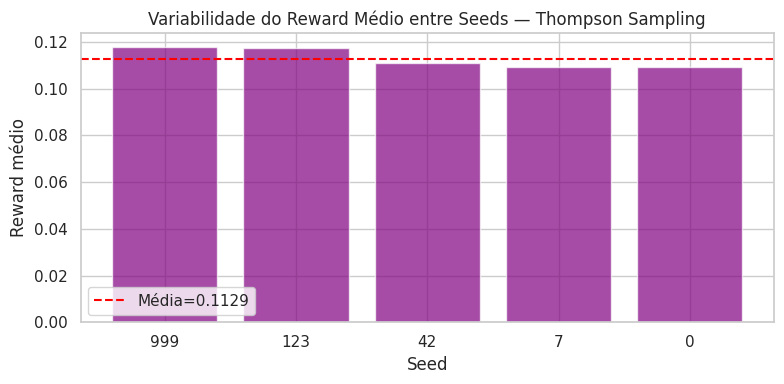

In [5]:
ts_runs = runs_df[runs_df['tags.mlflow.runName'].str.startswith('Thompson Sampling (seed=', na=False)]

if 'metrics.avg_reward' in ts_runs.columns and len(ts_runs) > 0:
    rewards = ts_runs['metrics.avg_reward'].dropna()
    print(f'Reward médio: {rewards.mean():.4f} ± {rewards.std():.4f}')
    print(f'Min: {rewards.min():.4f}  Max: {rewards.max():.4f}')

    fig, ax = plt.subplots(figsize=(8, 4))
    seeds_list = ts_runs['params.seed'].astype(str)
    ax.bar(seeds_list, rewards.values, color='purple', alpha=0.7)
    ax.axhline(rewards.mean(), linestyle='--', color='red', label=f'Média={rewards.mean():.4f}')
    ax.set_title('Variabilidade do Reward Médio entre Seeds — Thompson Sampling')
    ax.set_xlabel('Seed')
    ax.set_ylabel('Reward médio')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum run de Thompson Sampling (seed=...) encontrado ainda.')

## Identificando o melhor run

In [6]:
if 'metrics.avg_reward' in runs_df.columns and not runs_df['metrics.avg_reward'].isna().all():
    best_run = runs_df.loc[runs_df['metrics.avg_reward'].idxmax()]
    print('Melhor run por avg_reward:')
    for col in display_cols:
        if col in best_run.index:
            print(f'  {col}: {best_run[col]}')
else:
    print('Nenhuma métrica avg_reward disponível ainda.')

Melhor run por avg_reward:
  tags.mlflow.runName: Thompson Sampling (seed=999)
  params.policy_version: thompson-v1
  params.seed: 999
  metrics.avg_reward: 0.118
  metrics.final_regret: 6.7967
  metrics.best_arm_pct: 74.2
  metrics.rounds: 10281.0
  run_id: e4a94d225647436c9d418f9af92a8f84


## Registrando o melhor modelo no Model Registry

O MLflow Model Registry permite versionar a política e promovê-la de `Staging` para `Production`.

In [7]:
import mlflow.sklearn
import tempfile, pickle
from pathlib import Path

# Treina a política final com seed=42 (melhor seed padrão do projeto)
final_policy = ThompsonSamplingPolicy(seed=42)
df_final = replay_evaluate(final_policy, events, seed=42)

# Serializa a política como artefato
MODEL_NAME = 'offerexp-thompson-sampling'

exp_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
exp_id = exp_id.experiment_id if exp_id else mlflow.create_experiment(EXPERIMENT_NAME)

with mlflow.start_run(experiment_id=exp_id, run_name='model-registry-registration') as run:
    mlflow.log_params({
        'policy': 'Thompson Sampling',
        'policy_version': final_policy.version,
        'n_arms': final_policy.n_arms,
        'seed': 42,
    })
    mlflow.log_metrics({
        'avg_reward': round(df_final['avg_reward'].iloc[-1], 4) if not df_final.empty else 0,
        'rounds': len(df_final),
    })

    # Salva estado do modelo (alpha/beta dos braços)
    with tempfile.TemporaryDirectory() as tmp:
        model_path = Path(tmp) / 'policy_state.pkl'
        with open(model_path, 'wb') as f:
            pickle.dump({
                'version': final_policy.version,
                'arms': final_policy.arms,
                'trials': final_policy.trials,
                'successes': final_policy.successes,
            }, f)
        mlflow.log_artifact(str(model_path), artifact_path='model')

    registered_run_id = run.info.run_id
    print(f'Run registrado: {registered_run_id}')

print('Estado final dos braços:')
print(pd.DataFrame(final_policy.stats())[['arm_name', 'trials', 'successes', 'reward_rate', 'alpha', 'beta']].to_string(index=False))

Run registrado: d2dd4daf78d746d7b8f0bb83959cf49b
Estado final dos braços:
           arm_name  trials  successes  reward_rate  alpha  beta
         sem_oferta     381          8       0.0210      9   374
educacao_financeira    4434        835       0.1883    836  3600
  simulador_credito    2697        138       0.0512    139  2560
     cartao_premium    2660        148       0.0556    149  2513


## Abrindo o MLflow UI

Para explorar visualmente todos os experimentos:

```bash
# No terminal, a partir da raiz do projeto:
make mlflow
# ou diretamente:
mlflow ui --backend-store-uri ./mlruns --port 5000
```

Acesse: **http://localhost:5000**

### O que você verá no MLflow UI

| Seção | Conteúdo |
|-------|----------|
| **Experiments** | `offerexp-bandits` com todos os runs |
| **Runs** | Random, Greedy, Thompson Sampling (múltiplos seeds) |
| **Metrics** | avg_reward, final_regret, best_arm_pct, rounds |
| **Step metrics** | step_avg_reward e step_cumulative_regret ao longo do tempo |
| **Artifacts** | eval_results.csv, comparison_table.csv, policy_state.pkl, plots PNG |
| **Models** | Histórico de estados da política Thompson Sampling |